# Metropolis-Hastings algorithm

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data_full = pd.read_table("../data/Pantheon_SH0ES.dat", delimiter=" ")
print(len(data_full))
data_full.head()

1701


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


In [3]:
cov_full = np.loadtxt("../data/Pantheon_SH0ES_STAT_SYS.cov", skiprows=1).reshape(len(data_full), len(data_full))

In [4]:
mask = (data_full["USED_IN_SH0ES_HF"] == 1).to_numpy()
print(f"{mask.sum()} / {len(mask)}")

277 / 1701


In [5]:
data = data_full[mask]
cov = cov_full[np.ix_(mask, mask)]

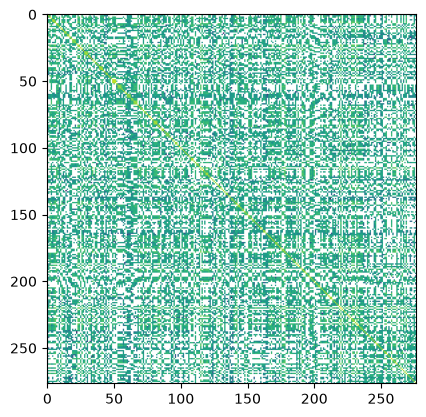

In [6]:
plt.imshow(cov, norm="log")

In [7]:
print(data.columns)
data.head()

Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='str')


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
341,2009cz,56,0.02343,0.00085,0.02315,0.00001,0.02227,0.00001,15.6052,0.258869,...,0.2198,22,6.11632,0.99966,0.1321,0.0797,-0.0560,0.001,1.0,0.007
342,2009cz,5,0.02343,0.00085,0.02315,0.00001,0.02227,0.00001,15.6052,0.168487,...,0.0479,28,8.37327,0.99988,0.0520,0.0797,-0.0352,0.001,1.0,0.004
343,ASASSN-15nr,150,0.02344,0.00087,0.02309,0.00018,0.02320,0.00018,15.5801,0.262385,...,0.1506,8,10.03640,0.26248,0.0792,0.0815,0.0387,0.002,1.0,0.018
344,2004bk,57,0.02352,0.00085,0.02405,0.00001,0.02306,0.00001,15.5861,0.214185,...,0.2801,41,38.97380,0.56101,0.0615,0.0794,0.0112,0.002,1.0,0.009
346,2007qe,57,0.02357,0.00085,0.02280,0.00005,0.02396,0.00005,15.7876,0.204800,...,0.0533,33,39.40670,0.20508,0.0590,0.0792,0.0116,0.002,1.0,0.010


In [8]:
from astropy import units as u
from astropy.cosmology import WMAP9 as cosmo

D_L_ref = np.array([cosmo.luminosity_distance(z).to(u.Mpc).value for z in data["zHD"]])

In [9]:
def m_b_hf(H0: float, M_B: float) -> np.ndarray:
    D_L = D_L_ref * (cosmo.H0.value / H0)
    return 25 + 5 * np.log10(D_L) + M_B

In [11]:
inv_cov = np.linalg.inv(cov)

In [12]:
def loglike(H0: float, M_B: float) -> float:
    residuals = m_b_hf(H0, M_B) - data["m_b_corr"].to_numpy()
    return -0.5 * residuals.T @ inv_cov @ residuals

In [17]:
import pymc as pm

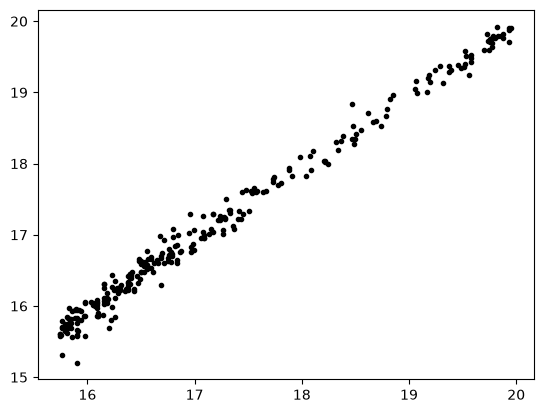

In [31]:
th = m_b_hf(70, -19.3)
obs = data["m_b_corr"].to_numpy()

plt.scatter(th, obs, marker=".", color="k")

In [60]:
with pm.Model() as model:
    H0 = pm.Uniform("H0", lower=60, upper=80)
    M_B = pm.Normal("M_B", mu=-19.3, sigma=0.1)
    obs = pm.MvNormal("obs", mu=m_b_hf(H0, M_B), cov=cov, observed=data["m_b_corr"].to_numpy())
    print(model.initial_point())
    idata = pm.sample(10_000, initvals={"H0": 75, "M_B": -19.2})

NUTS[nutpie]: [H0, M_B]


{'H0_interval__': array(nan), 'M_B': array(-19.3)}


Output()

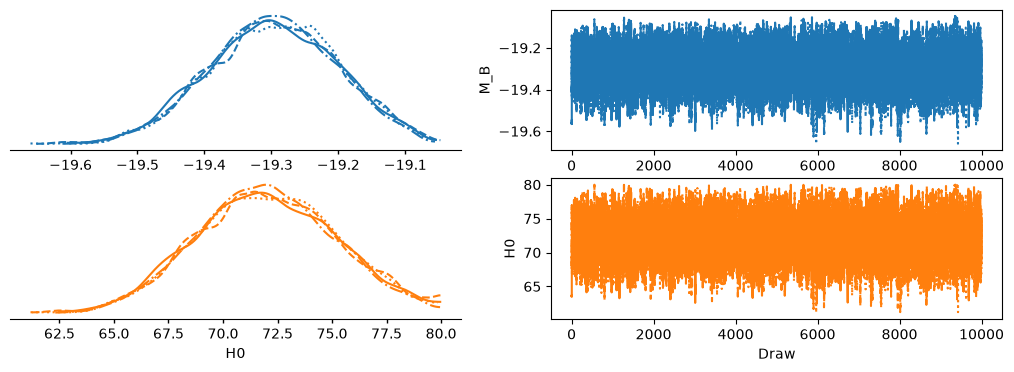

In [61]:
import arviz as az

az.plot_trace_dist(idata);

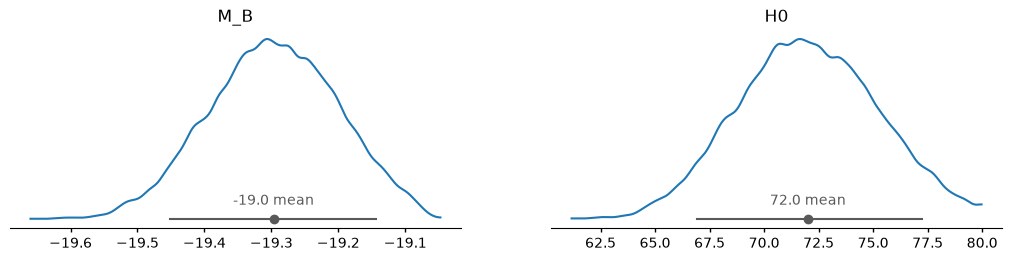

In [62]:
az.plot_dist(idata);

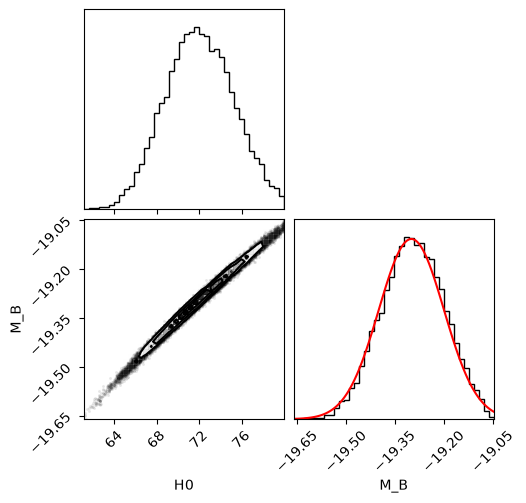

In [67]:
import corner
from scipy import stats

H0_sample = idata.posterior["H0"].to_numpy().flatten()
Mb_sample = idata.posterior["M_B"].to_numpy().flatten()

fig = corner.corner(
    np.column_stack((H0_sample, Mb_sample)),
    labels=["H0", "M_B"],
    hist_kwargs={"density": True},
    bins=40,
)
M_B_lim = fig.axes[-1].get_xlim()
M_B_grid = np.linspace(M_B_lim[0], M_B_lim[1], 100)
M_B_pdf = stats.norm.pdf(M_B_grid, loc=-19.3, scale=0.1)
fig.axes[-1].plot(M_B_grid, M_B_pdf, color="red")